In [1]:
import torch as nn 
import torch.nn as nn 
import torch.nn.functional as F
import torch.optim as optim
from torch.optim import SGD
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
import pandas as pd 
import numpy as np 

import os
# change working directory
os.chdir('/Users/gerardogutierrez/Desktop/Academics/Spring_2026/plant-health-status/Notebooks')

pd.set_option('display.max_columns', None)  # Show all columns in DataFrame display

In [2]:
import os, random
import numpy as np
import torch

def set_seed(seed=42):
    random.seed(seed)
    np.random.seed(seed)
    os.environ["PYTHONHASHSEED"] = str(seed)

    torch.manual_seed(seed)
    if torch.cuda.is_available():
        torch.cuda.manual_seed(seed)
        torch.cuda.manual_seed_all(seed)

set_seed(42)

Epoch [1/1000], Train Loss: 16153.4268, Val Loss: 23700.3926
Epoch [2/1000], Train Loss: 16149.4111, Val Loss: 23695.0703
Epoch [3/1000], Train Loss: 16145.4170, Val Loss: 23689.8184
Epoch [4/1000], Train Loss: 16141.4424, Val Loss: 23684.6035
Epoch [5/1000], Train Loss: 16137.4717, Val Loss: 23679.4238
Epoch [6/1000], Train Loss: 16133.4951, Val Loss: 23674.2285
Epoch [7/1000], Train Loss: 16129.5029, Val Loss: 23669.0254
Epoch [8/1000], Train Loss: 16125.5117, Val Loss: 23663.8457
Epoch [9/1000], Train Loss: 16121.5156, Val Loss: 23658.7090
Epoch [10/1000], Train Loss: 16117.5244, Val Loss: 23653.4844
Epoch [11/1000], Train Loss: 16113.5312, Val Loss: 23648.2578
Epoch [12/1000], Train Loss: 16109.5391, Val Loss: 23643.0469
Epoch [13/1000], Train Loss: 16105.5596, Val Loss: 23637.8184
Epoch [14/1000], Train Loss: 16101.5732, Val Loss: 23632.5527
Epoch [15/1000], Train Loss: 16097.5820, Val Loss: 23627.2480
Epoch [16/1000], Train Loss: 16093.5791, Val Loss: 23621.9121
Epoch [17/1000], 

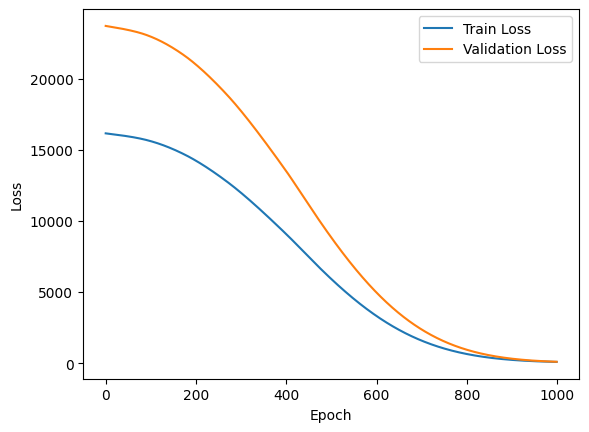

In [3]:
# load data 

import torch


df = (pd.read_csv('../Data/modeling_data.csv')
      )

target_col = 'total_fresh_weight_g'

X = df.drop(columns=[target_col]).to_numpy(dtype=np.float32)
y = df[target_col].to_numpy(dtype=np.float32).reshape(-1, 1)

feature_names = df.drop(columns=[target_col]).columns.tolist()


X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# standardize 
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train).astype(np.float32)
X_test = scaler.transform(X_test).astype(np.float32)

# convert to tensors
X_train_tensor = torch.tensor(X_train, dtype=torch.float32)
y_train_tensor = torch.tensor(y_train, dtype=torch.float32).view(-1, 1)
X_test_tensor = torch.tensor(X_test, dtype=torch.float32)
y_test_tensor = torch.tensor(y_test, dtype=torch.float32).view(-1, 1)


#### Neural Network Model
class BasicNN(nn.Module): # inherits from Module
    def __init__(self, input_size, hidden_size, output_size):
        super().__init__() # call initialization from module
        self.fc1 = nn.Linear(input_size, hidden_size)
        self.relu = nn.ReLU()
        self.fc2 = nn.Linear(hidden_size, output_size)

    def forward(self, x):
        x = self.fc1(x)
        x = self.relu(x)
        x = self.fc2(x)

        return x
    


# hyperparameters    
input_size = X_train_tensor.shape[1]
hidden_size = 32
output_size = 1
learning_rate = .001
num_epochs = 1000

# initialize model
model = BasicNN(input_size=input_size, hidden_size=hidden_size, output_size=output_size)

# loss function
criterion = nn.MSELoss()
optimizer = optim.Adam(model.parameters(), lr=learning_rate)


# train
train_losses = []
val_losses = []

for epoch in range(num_epochs):

    ### training
    model.train()
    outputs = model(X_train_tensor)
    loss = criterion(outputs, y_train_tensor)
    optimizer.zero_grad() 
    loss.backward() # compute gradients
    optimizer.step() # update weights

    train_losses.append(loss.item())

    ### validation
    model.eval()
    with torch.no_grad():
        val_outputs = model(X_test_tensor)
        val_loss = criterion(val_outputs, y_test_tensor)

    val_losses.append(val_loss.item())

    print(f"Epoch [{epoch+1}/{num_epochs}], "
            f"Train Loss: {loss.item():.4f}, "
         f"Val Loss: {val_loss.item():.4f}")
    
import matplotlib.pyplot as plt

plt.plot(train_losses, label="Train Loss")
plt.plot(val_losses, label="Validation Loss")


plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.legend()
# save figure
plt.savefig('../Figures/training_validation_loss.png')
plt.show()

In [62]:
df

,total_fresh_weight_g,carbon_dioxide,temp_env,humidity,pressure,electrical_conductivity,volume,temp_nutr,volume_flow_rate,weight_lag_1,weight_lag_2
0,40.1,514.051020,22.520816,65.247347,99282.511633,1521.816327,11551.277959,25.308837,1.087551,33.1,29.1
1,43.4,514.051020,22.520816,65.247347,99282.511633,1521.816327,11551.277959,25.308837,1.087551,36.3,30.1
2,43.6,514.051020,22.520816,65.247347,99282.511633,1521.816327,11551.277959,25.308837,1.087551,36.5,29.8
3,44.3,514.051020,22.520816,65.247347,99282.511633,1521.816327,11551.277959,25.308837,1.087551,38.1,29.7
4,45.0,514.051020,22.520816,65.247347,99282.511633,1521.816327,11551.277959,25.308837,1.087551,40.1,33.1
5,45.1,514.051020,22.520816,65.247347,99282.511633,1521.816327,11551.277959,25.308837,1.087551,38.5,30.2
6,46.0,514.051020,22.520816,65.247347,99282.511633,1521.816327,11551.277959,25.308837,1.087551,39.2,29.3
7,46.2,514.051020,22.520816,65.247347,99282.511633,1521.816327,11551.277959,25.308837,1.087551,39.2,30.4
8,46.8,514.051020,22.520816,65.247347,99282.511633,1521.816327,11551.277959,25.308837,1.087551,36.9,29.6
9,49.2,514.051020,22.520816,65.247347,99282.511633,1521.816327,11551.277959,25.308837,1.087551,42.1,31.8


In [63]:
class BasicNN(nn.Module):
    def __init__(self, input_size, hidden_size, output_size):
        super(BasicNN, self).__init__()

        self.fc1 = nn.Linear(input_size, hidden_size)
        self.relu = nn.ReLU()
        self.fc2 = nn.Linear(hidden_size, output_size)

    def forward(self, x):
        x = self.fc1(x)
        x = self.relu(x)
        x = self.fc2(x)
        
        return x 
        

Baseline RMSE: 10.351102

Permutation results (20-repeat average):
electrical_conductivity    RMSE=27.4403  (Δ=+17.0892,  sd=2.6749)
volume_flow_rate           RMSE=27.4002  (Δ=+17.0491,  sd=3.5086)
weight_lag_1               RMSE=27.2577  (Δ=+16.9066,  sd=3.1153)
temp_nutr                  RMSE=26.3365  (Δ=+15.9854,  sd=4.1457)
weight_lag_2               RMSE=24.2349  (Δ=+13.8838,  sd=2.4228)
volume                     RMSE=23.8278  (Δ=+13.4767,  sd=3.5889)
humidity                   RMSE=23.5083  (Δ=+13.1572,  sd=3.1101)
pressure                   RMSE=20.5875  (Δ=+10.2364,  sd=3.1687)
temp_env                   RMSE=18.7953  (Δ=+8.4442,  sd=2.7443)
carbon_dioxide             RMSE=16.9412  (Δ=+6.5901,  sd=2.4942)


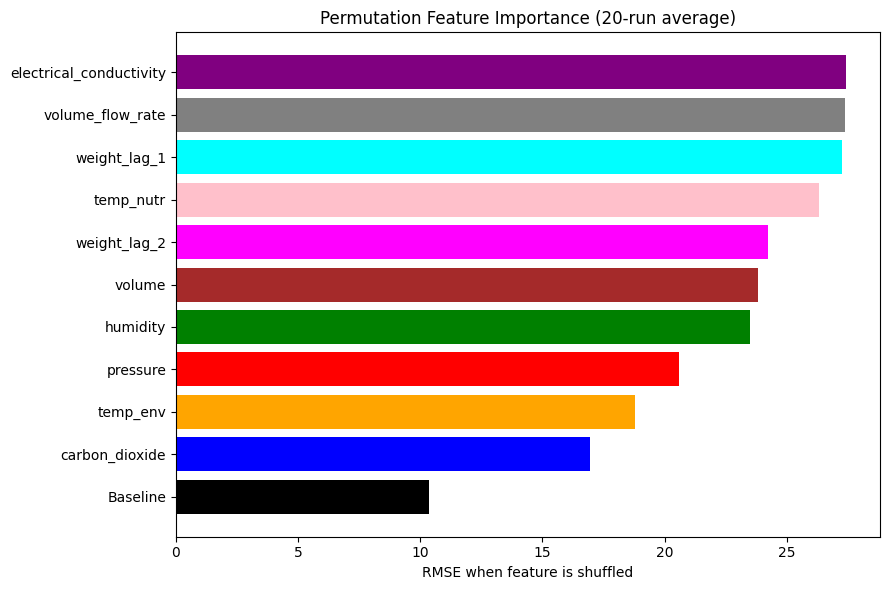

In [4]:
import numpy as np
import torch
import random
import matplotlib.pyplot as plt

# ==============================
# Set random seeds
# ==============================
seed = 42
random.seed(seed)
np.random.seed(seed)
torch.manual_seed(seed)
if torch.cuda.is_available():
    torch.cuda.manual_seed_all(seed)

# ==============================
# RMSE function
# ==============================
def rmse(y_pred, y_true):
    return np.sqrt(np.mean((y_pred - y_true) ** 2))

model.eval()

# ==============================
# Baseline RMSE
# ==============================
with torch.no_grad():
    base_preds = model(X_test_tensor).cpu().numpy()

y_true = y_test_tensor.cpu().numpy()
base_rmse = rmse(base_preds, y_true)

# ==============================
# Permutation Importance (20 repeats)
# ==============================
repeats = 20
perm_results = []

X_test_base = X_test_tensor.clone()
N = X_test_base.shape[0]

for j, name in enumerate(feature_names):
    rmses = []

    for r in range(repeats):
        X_perm = X_test_base.clone()

        # shuffle feature j
        idx = torch.randperm(N)
        X_perm[:, j] = X_perm[idx, j]

        with torch.no_grad():
            preds = model(X_perm).cpu().numpy()

        rmses.append(rmse(preds, y_true))

    avg_perm_rmse = np.mean(rmses)
    std_perm_rmse = np.std(rmses)

    perm_results.append((name, avg_perm_rmse, std_perm_rmse))

# Sort by average permuted RMSE (largest first)
perm_results.sort(key=lambda x: x[1], reverse=True)

# ==============================
# Print results
# ==============================
print("Baseline RMSE:", round(base_rmse, 6))
print("\nPermutation results (20-repeat average):")

for name, avg_rmse, std_rmse in perm_results:
    delta = avg_rmse - base_rmse
    print(f"{name:25s}  RMSE={avg_rmse:.4f}  (Δ={delta:+.4f},  sd={std_rmse:.4f})")

# ==============================
# Plot
# ==============================

coef_colors = {
    'carbon_dioxide': 'blue',
    'temp_env': 'orange',
    'humidity': 'green',
    'pressure': 'red',
    'electrical_conductivity': 'purple',
    'volume': 'brown',
    'temp_nutr': 'pink',
    'volume_flow_rate': 'gray',
    'weight_lag_1': 'cyan',
    'weight_lag_2': 'magenta'
}

baseline_color = "black"

names = [n for n, _, _ in perm_results]
rmses = [r for _, r, _ in perm_results]
colors = [coef_colors.get(name, 'black') for name in names]

# Add baseline as separate bar
names_plot = names + ["Baseline"]
rmses_plot = rmses + [base_rmse]
colors_plot = colors + [baseline_color]

plt.figure(figsize=(9, 6))
plt.barh(names_plot[::-1], rmses_plot[::-1], color=colors_plot[::-1])

plt.xlabel("RMSE when feature is shuffled")
plt.title("Permutation Feature Importance (20-run average)")
plt.tight_layout()

plt.savefig('../Figures/permutation_importance.png', bbox_inches='tight')
plt.show()

shows importance for automation per var


# Sensitivity analysis 
